# Response functions between arbitrary operators
The response of a single-particle Hamiltonian is a sum over transitions from an occupied state
at $k$ to an empty one at $k+q$, and nothing in that sum is specific to the density: a
perturbation that couples through an operator $B$ and a measurement of an operator $A$ give
$$
\chi_{AB}(q,\omega) = \sum_{k,n,m}
f(\epsilon_{k,n}) (1-f(\epsilon_{k+q,m}))
\frac{
\langle \Psi_{k,n}|A|\Psi_{k+q,m}\rangle
\langle \Psi_{k+q,m}|B|\Psi_{k,n}\rangle
}
{
\epsilon_{k,n} - \epsilon_{k+q,m} - \omega + i\delta
}
$$
`h.get_chi(A=...,B=...)` computes it for any pair of operators of the kind `h.get_operator()`
returns (spin, sublattice, valley, location...), and with no operators it is the charge-charge
response. Its imaginary part is the spectrum of the excitations that $B$ creates and $A$ detects.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Longitudinal and transverse spin response of a ferromagnetic chain
We take a chain with an exchange field $J$ along $z$, which splits the spin-up and spin-down
bands by $2J$, and compare two responses. $\chi_{s_z s_z}$ does not flip the spin, so it only
contains transitions inside each spin band and starts at zero frequency like the charge
response. $\chi_{s_x s_x}$ flips the spin, so every transition goes from one spin band to the
other: at $q=0$ all of them cost exactly the exchange splitting and the response is a single
line at $\omega=2J$, and at finite $q$ the kinetic energy of the pair spreads that line into a
continuum of spin-flip excitations, the Stoner continuum.

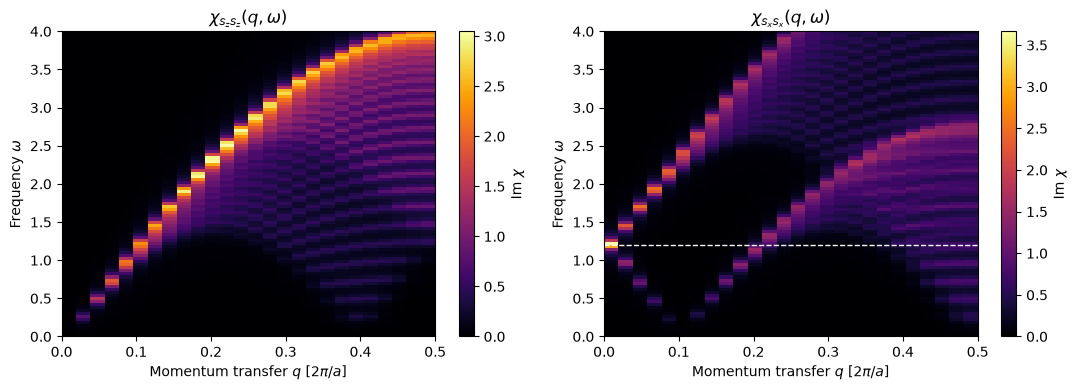

In [2]:
g = geometry.chain() # one-dimensional chain
h = g.get_hamiltonian(has_spin=True) # spinful Hamiltonian
J = 0.6 # exchange field
h.add_exchange([0.,0.,J]) # ferromagnet, spin splitting 2J
es = np.linspace(0.,4.,100) # frequencies
qs = np.linspace(0.,0.5,26) # momentum transfers, up to the zone boundary
maps = {} # storage
for op in ["sz","sx"]:
    maps[op] = np.array([h.get_chi(A=op,B=op,q=[q,0.,0.],energies=es,
                                   nk=100,delta=0.05)[1] for q in qs])

fig,axs = plt.subplots(1,2,figsize=(11,4))
for ax,op,name in zip(axs,["sz","sx"],["s_z s_z","s_x s_x"]):
    im = ax.imshow(maps[op].imag.T,origin="lower",aspect="auto",cmap="inferno",
                   extent=[qs[0],qs[-1],es[0],es[-1]])
    fig.colorbar(im,ax=ax,label=r"Im $\chi$")
    ax.set_xlabel("Momentum transfer $q$ [$2\\pi/a$]") ; ax.set_ylabel(r"Frequency $\omega$")
    ax.set_title(r"$\chi_{"+name+r"}(q,\omega)$")
axs[1].axhline(2*J,c="white",ls="--",lw=1) # the exchange splitting
plt.tight_layout()
plt.show()

The longitudinal response is the gapless particle-hole continuum of the two spin bands. The
transverse response is a single line at $2J$ at $q=0$, the dashed line, and opens into a
continuum as $q$ grows, which reaches zero frequency at $q=k_{F\uparrow}-k_{F\downarrow}$, the
momentum that connects the Fermi points of the two spin bands, where a spin flip costs nothing. Without interactions these are the only spin excitations; dressing
the transverse response with a Hubbard interaction at the RPA level is what pulls a magnon out
of the Stoner continuum, as in the notebook on RPA collective modes.